**Capítulo 2 - Um Projeto de Aprendizado de Máquina de Ponta a Ponta**

*Este notebook acompanha o fluxo completo de um projeto de aprendizado de máquina: baixar os dados, criar um conjunto de teste, explorar visualmente o conjunto de dados, preparar as variáveis, treinar modelos, ajustar hiperparâmetros, avaliar no conjunto de teste e persistir o modelo final.*

*Este notebook contém a tradução e adaptação das células de exemplo do Capítulo 2. A seção final de soluções dos exercícios foi deixada de fora de propósito, pois ficará em outro notebook.*

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [184]:
print("Welcome to Machine Learning!")

Welcome to Machine Learning!


# Configuração

*Antes de mexer nos dados, conferimos se o ambiente tem uma versão de Python compatível. Esse tipo de checagem evita erros difíceis de rastrear quando o notebook é executado em outra máquina.*

In [185]:
import sys

assert sys.version_info >= (3, 7)

*Também verificamos a versão do Scikit-Learn. O notebook usa recursos disponíveis a partir da versão 1.0.1, então é melhor falhar cedo se a instalação estiver antiga.*

In [186]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

# Obtenha os Dados

*A primeira etapa funcional do projeto é trazer o conjunto de dados para o ambiente local e carregá-lo em um DataFrame do Pandas. A partir daqui, todas as decisões serão baseadas nesse conjunto de dados.*

*Bem-vindo à Corporação de Habitação com Aprendizado de Máquina! Sua tarefa é prever o valor mediano das casas em distritos da Califórnia usando atributos desses distritos, como renda mediana, localização, população e características das moradias.*

## Faça o download dos Dados

*Esta célula baixa um arquivo compactado com os dados de habitação, extrai o CSV e devolve um DataFrame. A função cria a pasta `datasets/` apenas se ela ainda não existir, o que torna a execução repetível.*

In [187]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

/tmp/ipykernel_9862/2839428726.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


## Uma Rápida Olhada na Estrutura dos Dados

*Antes de modelar, precisamos entender o formato do conjunto de dados: quais colunas existem, quais tipos de dados aparecem, onde há valores ausentes e como os valores estão distribuídos.*

In [188]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [189]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [190]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [191]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


*A célula seguinte não aparece no livro. Ela cria a pasta `images/end_to_end_project`, caso ainda não exista, e define a função `save_fig()`, usada ao longo do notebook para salvar figuras em alta resolução.*

In [192]:
# código extra – código para salvar as figuras como PNGs de alta resolução para o livro

IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

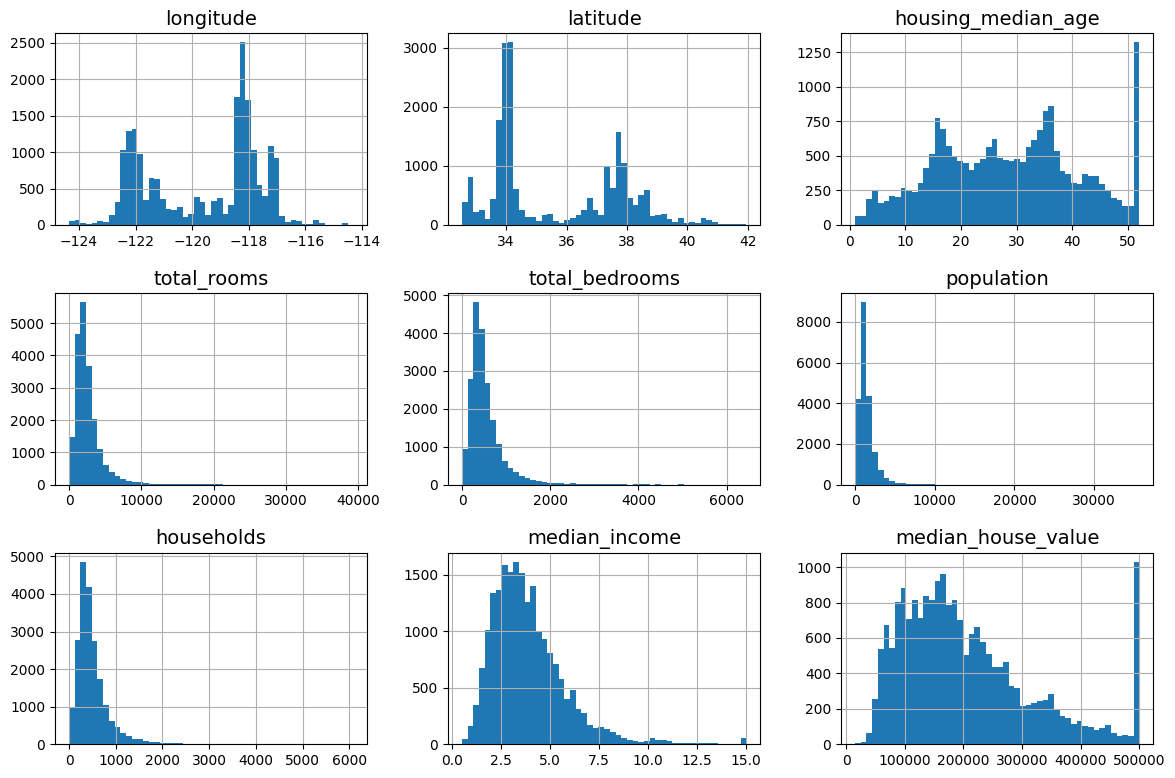

In [193]:
import matplotlib.pyplot as plt

# código extra – as próximas 5 linhas definem os tamanhos padrão das fontes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # código extra
plt.show()

## Crie um Conjunto de Teste

*Separar um conjunto de teste logo no início é uma proteção contra o viés de espiar os dados. O modelo e nossas decisões de exploração devem ser guiados apenas pelo treino; o teste fica reservado para uma estimativa final mais honesta.*

In [194]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [195]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)
len(train_set)

16512

In [196]:
len(test_set)

4128

*Para que as saídas deste notebook permaneçam iguais a cada execução, definimos uma semente aleatória fixa.*

In [197]:
np.random.seed(42)

*Isso ainda não garante resultados exatamente idênticos aos do livro, pois bibliotecas evoluem e algoritmos podem mudar pequenos detalhes entre versões. Diferenças pequenas são esperadas; o importante é que os resultados fiquem na mesma ordem de grandeza.*

*Observação: outra fonte de aleatoriedade é a ordem dos conjuntos (`set`) em Python, baseada na função `hash()`, que recebe um "sal" aleatório quando o Python inicia. Para remover essa variação, seria necessário definir `PYTHONHASHSEED="0"` antes de iniciar o Python. No Colab, essa variável normalmente já vem configurada.*

In [198]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [199]:
housing_with_id = housing.reset_index()  # adiciona uma coluna `index`
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [200]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [201]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [202]:
test_set["total_bedrooms"].isnull().sum()

np.int64(44)

*Para encontrar a probabilidade de uma amostra aleatória de 1.000 pessoas conter menos de 48,5% ou mais de 53,5% de mulheres, quando a proporção real é 51,1%, usamos a [distribuição binomial](https://en.wikipedia.org/wiki/Binomial_distribution). O método `cdf()` retorna a probabilidade acumulada até certo número de ocorrências.*

In [203]:
# código extra – mostra como calcular a probabilidade de 10,7% de obter uma amostra ruim

from scipy.stats import binom

sample_size = 1000
ratio_female = 0.511
proba_too_small = binom(sample_size, ratio_female).cdf(485 - 1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(535)
print(proba_too_small + proba_too_large)

0.10736798530930253


*Se você preferir simulação em vez de cálculo analítico, a célula abaixo estima aproximadamente a mesma probabilidade repetindo muitas amostragens aleatórias.*

In [204]:
# código extra – mostra outra forma de estimar a probabilidade de uma amostra ruim

np.random.seed(42)

samples = (np.random.rand(100_000, sample_size) < ratio_female).sum(axis=1)
((samples < 485) | (samples > 535)).mean()

np.float64(0.1071)

In [205]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

*Depois de criar a coluna `income_cat`, visualizamos quantos distritos caem em cada faixa de renda. Esse gráfico serve para confirmar se as categorias ficaram bem distribuídas e se fazem sentido antes de usá-las na amostragem estratificada.*

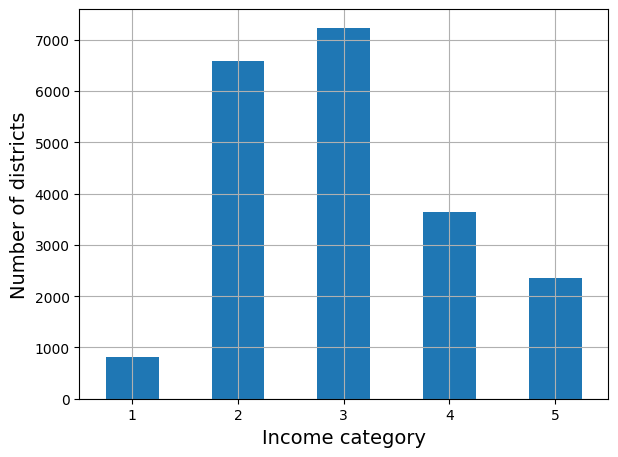

In [206]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
save_fig("housing_income_cat_bar_plot")  # código extra
plt.show()

*Agora usamos `StratifiedShuffleSplit` para gerar divisões treino/teste preservando a proporção das categorias de renda. O laço percorre os índices produzidos pelo separador, monta os subconjuntos correspondentes com `iloc` e guarda cada divisão em `strat_splits` para podermos escolher uma delas depois.*

In [207]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [208]:
strat_train_set, strat_test_set = strat_splits[0]

*O Scikit-Learn também oferece uma forma mais curta de obter uma divisão estratificada usando `train_test_split()` com o argumento `stratify`.*

In [209]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [210]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [211]:
# código extra – calcula os dados para a Figura 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


In [212]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Explore e Visualize os Dados para Ter Informações Úteis

*Agora exploramos apenas o conjunto de treino. O objetivo é ganhar intuição sobre padrões geográficos, correlações, valores atípicos e combinações de atributos que possam ajudar o modelo.*

In [213]:
housing = strat_train_set.copy()

## Visualizando Dados Geográficos

*Como o conjunto de dados contém latitude e longitude, gráficos de dispersão ajudam a revelar concentração de distritos, áreas costeiras e regiões associadas a preços mais altos.*

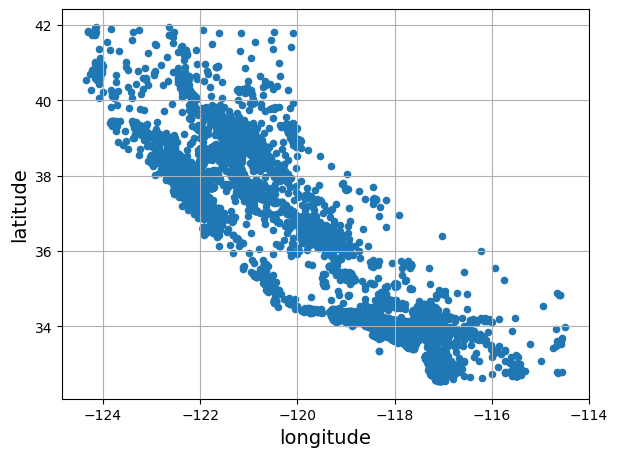

In [214]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
save_fig("bad_visualization_plot")  # código extra
plt.show()

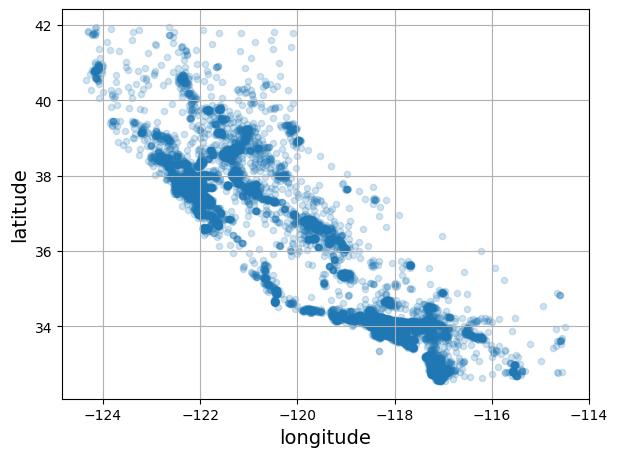

In [215]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
save_fig("better_visualization_plot")  # código extra
plt.show()

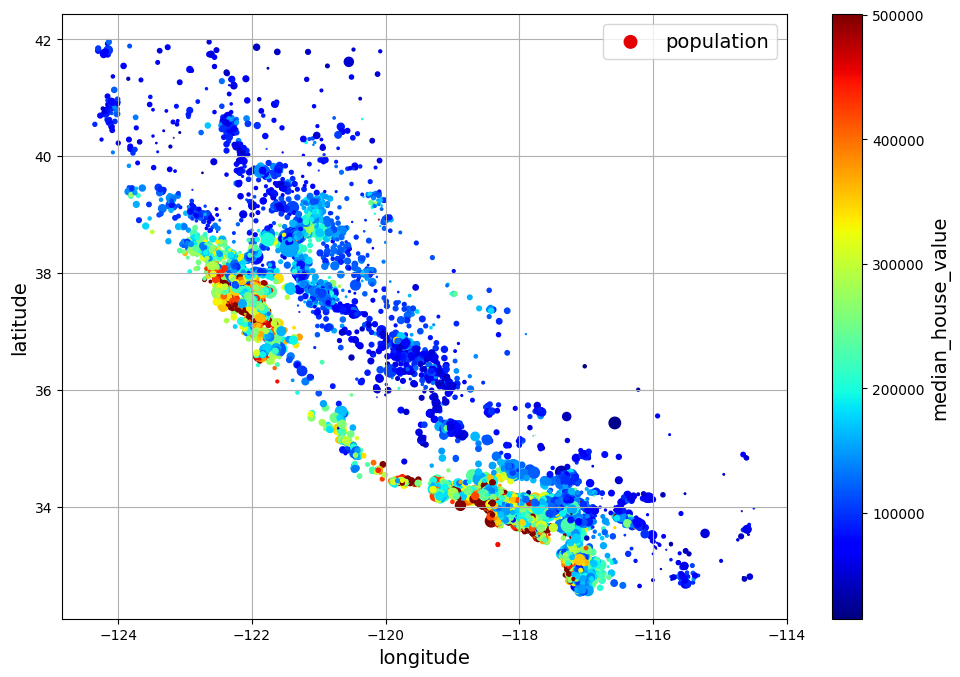

In [216]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
save_fig("housing_prices_scatterplot")  # código extra
plt.show()

*O argumento `sharex=False` contorna um bug visual do Pandas: sem ele, os valores e o rótulo do eixo x podem não aparecer corretamente. Veja: https://github.com/pandas-dev/pandas/issues/10611.*

*A próxima célula gera a primeira figura do capítulo. Ela não está no livro em forma de código: é uma versão mais bonita do gráfico anterior, com mapa da Califórnia ao fundo, rótulos melhores e sem grade.*

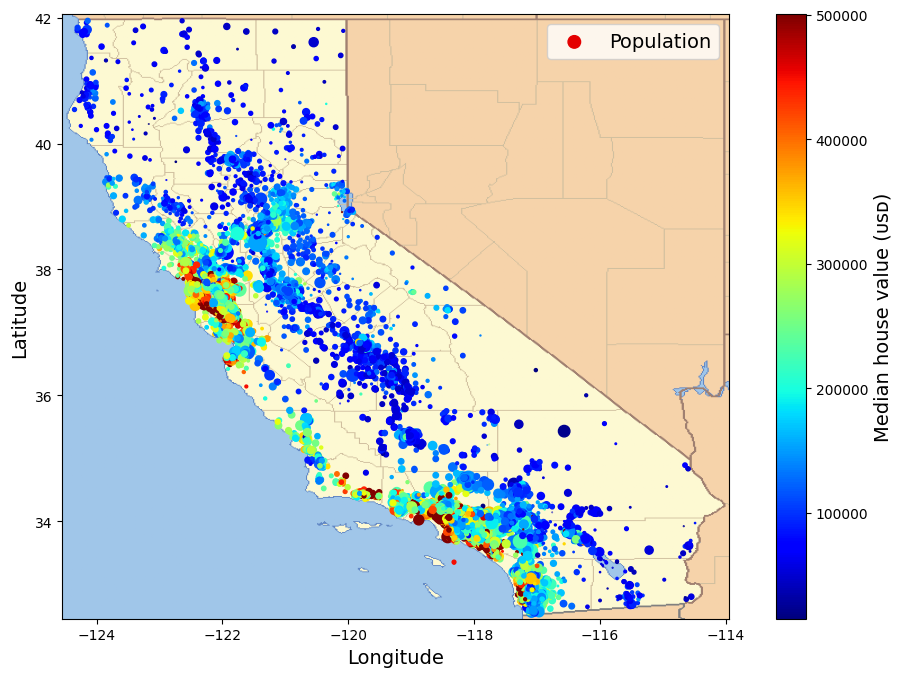

In [217]:
# código extra – esta célula gera a primeira figura do capítulo

# Baixa a imagem da Califórnia
filename = "california.png"
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

save_fig("california_housing_prices_plot")
plt.show()

## Buscando Correlações

*Correlação mede associação linear entre variáveis. Aqui usamos essa ferramenta para descobrir quais atributos parecem mais relacionados ao valor mediano das casas.*

*Nota: a partir do Pandas 2.0.0, `numeric_only` passou a ter `False` como padrão. Definimos `numeric_only=True` para evitar erro ao calcular correlações em colunas categóricas.*

In [218]:
corr_matrix = housing.corr(numeric_only=True)

In [219]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

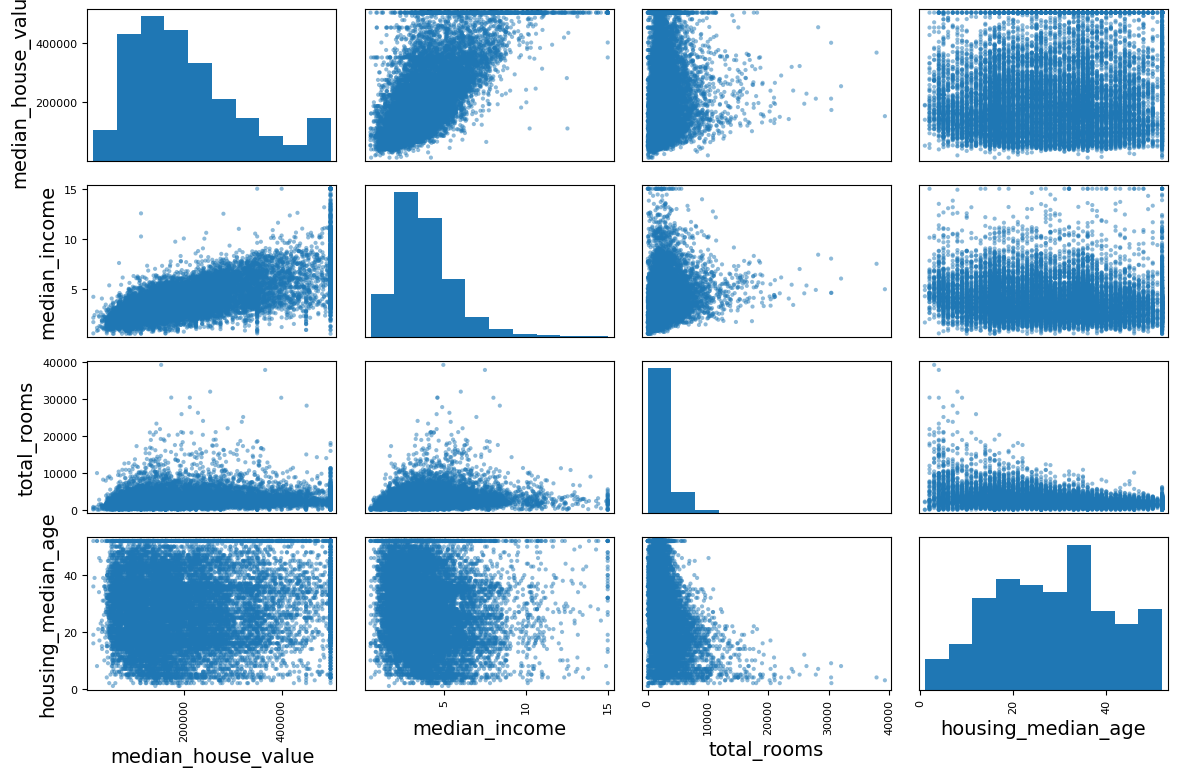

In [220]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # código extra
plt.show()

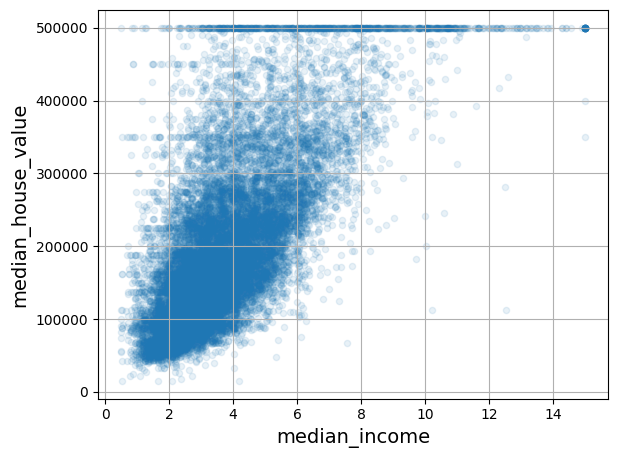

In [221]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
save_fig("income_vs_house_value_scatterplot")  # código extra
plt.show()

## Teste Combinações de Atributos

*Algumas razões fazem mais sentido do que as colunas brutas. Por exemplo, quartos por residência ou pessoas por residência podem representar melhor a realidade de cada distrito.*

In [222]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [223]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

# Prepare os Dados para Algoritmos de ML
*Nesta etapa transformamos o conjunto de dados bruto em uma matriz adequada para modelos: separamos o alvo, tratamos valores ausentes, codificamos categorias, ajustamos escalas e empacotamos tudo em encadeamentos reutilizáveis.*

*Vamos voltar ao conjunto de treino original e separar o alvo. Observe que `strat_train_set.drop()` cria uma cópia sem a coluna `median_house_value`; ele não modifica `strat_train_set` de verdade, a menos que `inplace=True` seja passado.*

In [224]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## Limpe os Dados

*Modelos de aprendizado de máquina não lidam bem com `NaN` por padrão. Antes de treinar, precisamos escolher uma estratégia consistente para preencher ou remover valores ausentes.*

No livro, três opções são listadas para lidar com valores `NaN`:

```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # opção 1
housing.drop("total_bedrooms", axis=1)                     # opção 2
median = housing["total_bedrooms"].median()                # opção 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

*Para cada opção, criaremos uma cópia de `housing` e trabalharemos nessa cópia, evitando quebrar o DataFrame original. Também filtramos as linhas que originalmente tinham valores ausentes para enxergar claramente o efeito de cada alternativa.*

In [225]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


In [226]:
housing_option1 = housing.copy()

housing_option1.dropna(subset=["total_bedrooms"], inplace=True)  # opção 1

housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [227]:
housing_option2 = housing.copy()

housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # opção 2

housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


In [228]:
housing_option3 = housing.copy()

median = housing["total_bedrooms"].median()
housing_option3["total_bedrooms"].fillna(median, inplace=True)  # opção 3

housing_option3.loc[null_rows_idx].head()

/tmp/ipykernel_9862/3218827148.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_option3["total_bedrooms"].fillna(median, inplace=True)  # opção 3


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN


In [229]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

*Separamos os atributos numéricos para usar a estratégia `"median"`, pois a mediana não pode ser calculada em atributos textuais como `ocean_proximity`.*

In [230]:
housing_num = housing.select_dtypes(include=[np.number])

In [231]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [232]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

*Vamos conferir se as estatísticas aprendidas pelo `SimpleImputer` são as mesmas medianas que calcularíamos manualmente em cada atributo.*

In [233]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

*Agora transformamos o conjunto de treino: o `imputer` substitui os valores ausentes pelas medianas aprendidas no `fit()`.*

In [234]:
X = imputer.transform(housing_num)

In [235]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [236]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [237]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [238]:
imputer.strategy

'median'

In [239]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [240]:
housing_tr.loc[null_rows_idx].head()  # não mostrado no livro

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [241]:
# from sklearn import set_config

# set_config(transform_output="pandas")  # scikit-learn >= 1.2

*Também podemos detectar valores atípicos. Aqui usamos `IsolationForest`, que tenta identificar exemplos incomuns em relação ao restante dos dados.*

In [242]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)

In [243]:
outlier_pred

array([-1,  1,  1, ...,  1,  1,  1], shape=(16512,))

*Se você quisesse remover os valores atípicos detectados, executaria o código abaixo. Ele fica comentado porque remover valores atípicos é uma decisão de modelagem que precisa ser justificada caso a caso.*

In [244]:
# housing = housing.iloc[outlier_pred == 1]
# housing_labels = housing_labels.iloc[outlier_pred == 1]

## Manipulando Texto e Atributos Categóricos

*O atributo `ocean_proximity` é textual. Como a maioria dos algoritmos espera números, precisamos convertê-lo usando codificação ordinal ou codificação one-hot.*

*Vamos começar pré-processando a variável categórica de entrada `ocean_proximity`.*

In [245]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [246]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [247]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [248]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [249]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
cat_encoder.set_output(transform="default")
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [250]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

*Por padrão, `OneHotEncoder` retorna uma matriz esparsa, que economiza memória quando há muitos zeros. Se necessário, podemos convertê-la para array denso com `toarray()`.*

In [251]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

*Outra opção é criar o `OneHotEncoder` com `sparse_output=False`. Observação: o hiperparâmetro `sparse` foi renomeado para `sparse_output` no Scikit-Learn 1.2.*

In [252]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [253]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [254]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [255]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [256]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


In [257]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [258]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [259]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [260]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
                         columns=cat_encoder.get_feature_names_out(),
                         index=df_test_unknown.index)

In [261]:
df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0


## Escalonamento das Características e Transformação

*Os atributos numéricos estão em escalas muito diferentes. Escalonar os atributos ajuda vários algoritmos a treinar melhor e evita que variáveis com valores grandes dominem as demais.*

In [262]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [263]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

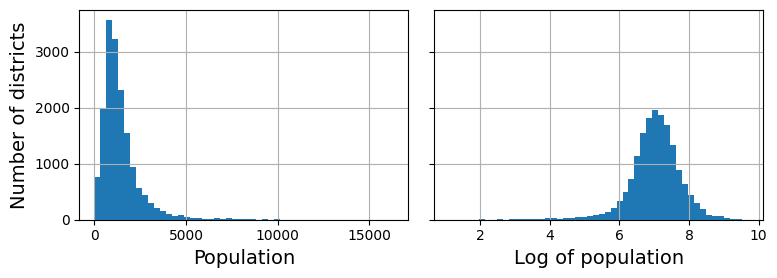

In [264]:
# código extra – esta célula gera a Figura 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

*E se substituirmos cada valor pelo seu percentil? Essa transformação tende a produzir uma distribuição quase uniforme, o que pode ajudar em alguns cenários.*

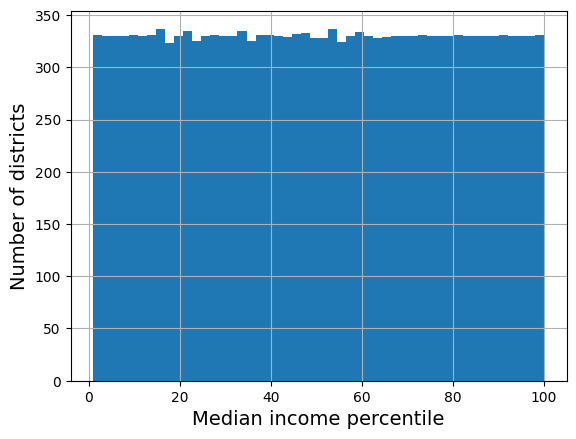

In [265]:
# código extra – apenas mostra que obtemos uma distribuição uniforme
percentiles = [np.percentile(housing["median_income"], p)
               for p in range(1, 100)]
flattened_median_income = pd.cut(housing["median_income"],
                                 bins=[-np.inf] + percentiles + [np.inf],
                                 labels=range(1, 100 + 1))
flattened_median_income.hist(bins=50)
plt.xlabel("Median income percentile")
plt.ylabel("Number of districts")
plt.show()
# Observação: rendas abaixo do 1º percentil são rotuladas como 1, e rendas acima do
# 99º percentil são rotuladas como 100. É por isso que a distribuição abaixo varia
# de 1 a 100 (não de 0 a 100).

In [266]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

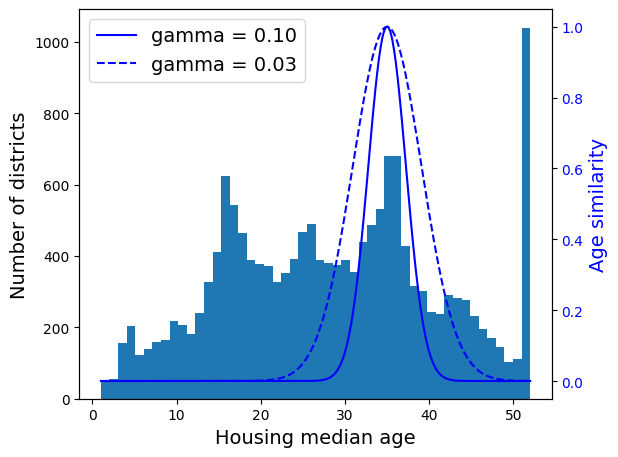

In [267]:
# código extra – esta célula gera a Figura 2–18

ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # cria um eixo gêmeo que compartilha o mesmo eixo x
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
save_fig("age_similarity_plot")
plt.show()

In [268]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]  # finja que estes são dados novos

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [269]:
predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

In [270]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

In [271]:
predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

## Transformadores Personalizados

*Quando as transformações prontas não bastam, podemos criar transformadores próprios seguindo a API do Scikit-Learn. Isso permite encaixá-los naturalmente em encadeamentos de pré-processamento.*

*Para criar transformadores simples, `FunctionTransformer` costuma ser suficiente: passamos uma função Python e ela passa a se comportar como uma etapa de pré-processamento.*

In [272]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [273]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [274]:
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]], shape=(16512, 1))

In [275]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

In [276]:
sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]], shape=(16512, 1))

In [277]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

In [278]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # sem *args nem **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y é exigido, embora não seja usado
        X = check_array(X)  # verifica se X é um array com valores float finitos
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # todo estimador armazena isso em fit()
        return self  # sempre retorne self!

    def transform(self, X):
        check_is_fitted(self)  # procura atributos aprendidos (com _ no final)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [279]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # sempre retorne self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Similaridade com o cluster {i}" for i in range(self.n_clusters)]

**Aviso**:
* Houve uma mudança no Scikit-Learn 1.3.0 que afetou o gerador de números aleatórios usado na inicialização do `KMeans`. Portanto, os resultados serão diferentes dos do livro se você usar Scikit-Learn >= 1.3. Isso não é um problema, desde que você não espere saídas perfeitamente idênticas.
* Ao longo deste notebook, quando `n_init` não era definido ao criar um estimador `KMeans`, definimos explicitamente `n_init=10` para evitar o aviso de que o valor padrão desse hiperparâmetro mudaria de 10 para `"auto"` no Scikit-Learn 1.4.
* O livro não deixou claro que definir `sample_weight=housing_labels` era apenas um exemplo; esse argumento não é realmente usado durante o treinamento. Por isso, removemos o argumento `sample_weight` abaixo, e a próxima figura corresponde aos clusters realmente usados no treinamento, ao contrário da Figura 2-19 do livro. Desculpe se isso causou alguma confusão!

In [280]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

In [281]:
similarities[:3].round(2)

array([[0.  , 0.97, 0.  , 0.  , 0.  , 0.08, 0.  , 0.  , 0.13, 0.57],
       [0.12, 0.  , 0.98, 0.03, 0.  , 0.  , 0.  , 0.54, 0.  , 0.  ],
       [0.  , 0.75, 0.  , 0.  , 0.  , 0.44, 0.  , 0.  , 0.27, 0.28]])

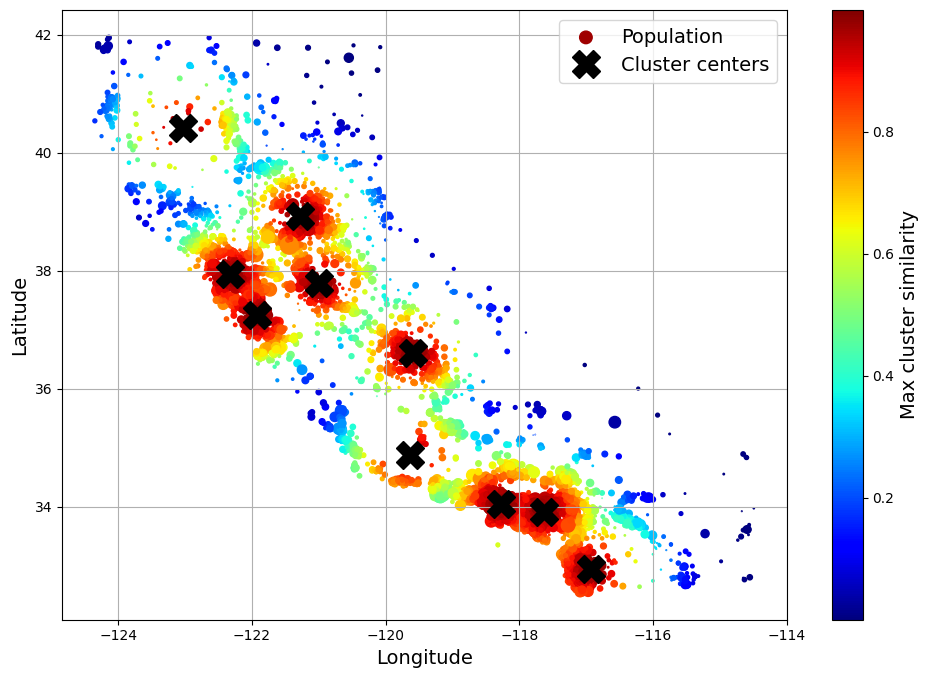

In [282]:
# código extra – esta célula gera a Figura 2–19

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
save_fig("district_cluster_plot")
plt.show()

## Transformação de Pipelines

*Encadeamentos organizam várias etapas de pré-processamento em uma sequência única. Isso reduz repetição, evita vazamento de dados e garante que treino, validação e produção usem exatamente as mesmas transformações.*

*Vamos construir primeiro um encadeamento para os atributos numéricos.*

In [283]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

In [284]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [285]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [286]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [287]:
def monkey_patch_get_signature_names_out():
    """Monkey patch some classes which did not handle get_feature_names_out()
       correctly in Scikit-Learn 1.0.*."""
    from inspect import Signature, signature, Parameter
    import pandas as pd
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import make_pipeline, Pipeline
    from sklearn.preprocessing import FunctionTransformer, StandardScaler

    default_get_feature_names_out = StandardScaler.get_feature_names_out

    if not hasattr(SimpleImputer, "get_feature_names_out"):
      print("Monkey-patching SimpleImputer.get_feature_names_out()")
      SimpleImputer.get_feature_names_out = default_get_feature_names_out

    if not hasattr(FunctionTransformer, "get_feature_names_out"):
        print("Monkey-patching FunctionTransformer.get_feature_names_out()")
        orig_init = FunctionTransformer.__init__
        orig_sig = signature(orig_init)

        def __init__(*args, feature_names_out=None, **kwargs):
            orig_sig.bind(*args, **kwargs)
            orig_init(*args, **kwargs)
            args[0].feature_names_out = feature_names_out

        __init__.__signature__ = Signature(
            list(signature(orig_init).parameters.values()) + [
                Parameter("feature_names_out", Parameter.KEYWORD_ONLY)])

        def get_feature_names_out(self, names=None):
            if callable(self.feature_names_out):
                return self.feature_names_out(self, names)
            assert self.feature_names_out == "one-to-one"
            return default_get_feature_names_out(self, names)

        FunctionTransformer.__init__ = __init__
        FunctionTransformer.get_feature_names_out = get_feature_names_out

monkey_patch_get_signature_names_out()

In [288]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

In [289]:
df_housing_num_prepared.head(2)  # código extra

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942


In [290]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [291]:
num_pipeline[1]

StandardScaler()

In [292]:
num_pipeline[:-1]

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median'))])

In [293]:
num_pipeline.named_steps["simpleimputer"]

SimpleImputer(strategy='median')

In [294]:
num_pipeline.set_params(simpleimputer__strategy="median")

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [295]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])


In [296]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [297]:
housing_prepared = preprocessing.fit_transform(housing)

In [298]:
# código extra – mostra que podemos obter um DataFrame como saída se quisermos
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)
housing_prepared_fr.head(2)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0


In [299]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # nomes das características de saída

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # uma coluna restante: housing_median_age

In [300]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [301]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Similaridade com o cluster 0',
       'geo__Similaridade com o cluster 1',
       'geo__Similaridade com o cluster 2',
       'geo__Similaridade com o cluster 3',
       'geo__Similaridade com o cluster 4',
       'geo__Similaridade com o cluster 5',
       'geo__Similaridade com o cluster 6',
       'geo__Similaridade com o cluster 7',
       'geo__Similaridade com o cluster 8',
       'geo__Similaridade com o cluster 9',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN', 'remainder__housing_median_age'],
      dtype=object)

# Escolha e Treine um Modelo

*Com os dados preparados, podemos treinar modelos de regressão e comparar seus erros. Começamos com modelos simples e depois avançamos para alternativas mais flexíveis.*

## Treine e Avalie o Conjunto de Treinamento

*Primeiro treinamos no conjunto de treino e medimos o erro nesse mesmo conjunto. Essa avaliação é útil para diagnóstico inicial, mas não deve ser confundida com desempenho real em dados novos.*

In [302]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7fa...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3ac0dcf80>)])),
                ('linearregression', LinearRegression())])

*Vamos testar o encadeamento completo de pré-processamento em algumas instâncias de treino.*

In [303]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = arredondado para a centena mais próxima

array([242800., 375900., 127500.,  99400., 324600.])

*Agora comparamos as previsões com os valores reais correspondentes.*

In [304]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [305]:
# código extra – calcula as razões de erro discutidas no livro
error_ratios = housing_predictions[:5].round(-2) / housing_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-47.0%, -22.3%, 25.4%, 3.4%, -10.3%


**Aviso:** em versões recentes do Scikit-Learn, use `root_mean_squared_error(labels, predictions)` para calcular o RMSE, em vez de `mean_squared_error(labels, predictions, squared=False)`. O bloco `try`/`except` abaixo tenta importar `root_mean_squared_error`; se não conseguir, define uma função equivalente.

In [306]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

np.float64(68647.95686706669)

In [307]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7fa...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3ac0dcf80>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [308]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

np.float64(0.0)

## Avalie Melhor com a Validação Cruzada

*Avaliar apenas uma divisão treino/teste pode dar uma visão limitada. A validação cruzada treina e avalia o modelo em várias divisões do conjunto de treino, oferecendo uma estimativa mais estável do erro.*

In [309]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [310]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     67153.318273
std       1963.580924
min      63925.253106
25%      66083.277180
50%      66795.829871
75%      68074.018403
max      70664.635833
dtype: float64

In [311]:
# código extra – calcula as estatísticas de erro para o modelo linear
lin_rmses = -cross_val_score(lin_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     69847.923224
std       4078.407329
min      65659.761079
25%      68088.799156
50%      68697.591463
75%      69800.966364
max      80685.254832
dtype: float64

**Aviso:** a próxima célula pode levar alguns minutos para executar.

In [312]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [313]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47002.931706
std       1048.451340
min      45667.064036
25%      46494.358345
50%      47093.173938
75%      47274.873814
max      49354.705514
dtype: float64

*Vamos comparar o RMSE medido por validação cruzada, o "erro de validação", com o RMSE medido no próprio conjunto de treino, o "erro de treino".*

In [314]:
forest_reg.fit(housing, housing_labels)
housing_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
forest_rmse

np.float64(17547.52124624957)

*O erro de treino é muito menor que o erro de validação, o que geralmente indica sobreajuste: o modelo decorou detalhes do treino e generaliza pior. Outra possibilidade seria uma diferença entre treino e validação, mas aqui ambos vieram do mesmo conjunto de dados embaralhado e dividido.*

# Aperfeiçoe seu Modelo

*Depois de escolher uma família de modelo promissora, ajustamos hiperparâmetros para buscar uma combinação melhor. Faremos isso com busca em grade e busca aleatória.*

## Grid Search

*Na busca em grade, testamos combinações explícitas de hiperparâmetros. É simples e sistemática, mas pode ficar cara quando há muitos parâmetros ou muitos valores possíveis.*

**Aviso:** a próxima célula pode levar alguns minutos para executar.

In [315]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3ac0dcf80>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

*Você pode obter a lista completa de hiperparâmetros disponíveis para ajuste olhando `full_pipeline.get_params().keys()`.*

In [316]:
# código extra – mostra parte da saída de get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'prepro

*Melhor combinação de hiperparâmetros encontrada:*

In [317]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [318]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7fa38df...
                                                  ClusterSimilarity(n_clusters=15,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3b1917740>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

*Vamos olhar a pontuação de cada combinação de hiperparâmetros testada durante a busca em grade.*

In [319]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# código extra – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43536,43753,44569,43953
13,15,8,44084,44205,44863,44384
14,15,10,44368,44496,45200,44688
7,10,6,44251,44628,45857,44912
9,10,6,44251,44628,45857,44912


## Randomized Search

*Na busca aleatória, sorteamos combinações de hiperparâmetros a partir de distribuições. Ela costuma explorar espaços grandes com melhor custo-benefício do que uma grade rígida.*

In [320]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

*A configuração abaixo testa 30 combinações aleatórias de hiperparâmetros, pois são `n_iter` combinações multiplicadas por `cv` divisões de validação cruzada.*

**Aviso:** a próxima célula pode levar alguns minutos para executar.

In [321]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa3b18a7080>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa3b1a67920>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [322]:
# código extra – exibe os resultados da busca aleatória
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41115,42151,42695,41987
8,32,7,41604,42200,43219,42341
0,41,16,42106,42743,43443,42764
5,42,4,41812,42925,43557,42765
2,23,8,42421,43094,43856,43124


**Seção bônus: como escolher a distribuição de amostragem de um hiperparâmetro**

* `scipy.stats.randint(a, b+1)`: para hiperparâmetros com valores discretos de `a` até `b`, quando todos parecem igualmente prováveis.
* `scipy.stats.uniform(a, b)`: muito parecida, mas para hiperparâmetros contínuos.
* `scipy.stats.geom(1 / scale)`: para valores discretos quando queremos amostrar aproximadamente em uma escala. Por exemplo, com `scale=1000`, a maior parte das amostras fica nessa faixa, mas cerca de 10% fica muito acima e cerca de 10% fica muito abaixo.
* `scipy.stats.expon(scale)`: versão contínua da distribuição geométrica; útil quando queremos favorecer uma escala, mas ainda permitir valores maiores.
* `scipy.stats.loguniform(a, b)`: útil quando qualquer escala entre `a` e `b` parece igualmente provável, como entre 0,001, 0,01, 0,1, 1, 10, 100 e 1000.

*A seguir, vemos gráficos das funções de massa de probabilidade, para variáveis discretas, e das funções de densidade, para variáveis contínuas, usando `randint()`, `uniform()`, `geom()` e `expon()`.*

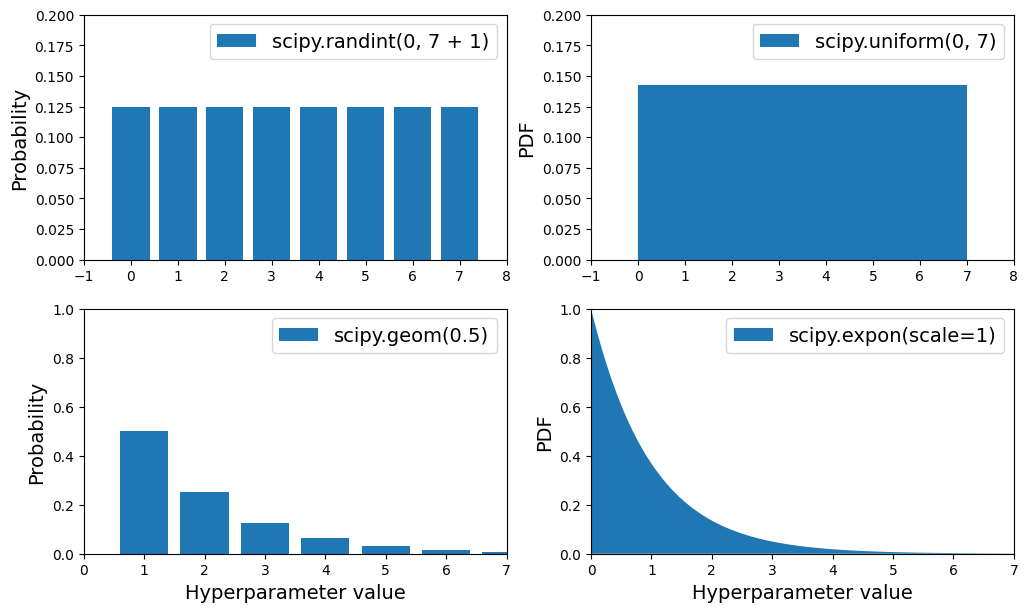

In [323]:
# código extra – plota algumas distribuições que você pode usar na busca aleatória

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

*Aqui comparamos as PDFs de `expon()` e `loguniform()` na coluna esquerda, e as PDFs de `log(X)` na coluna direita. A coluna direita mostra a distribuição das escalas dos hiperparâmetros. `expon()` favorece hiperparâmetros perto da escala desejada, com cauda para escalas menores; `loguniform()` não favorece nenhuma escala, deixando todas igualmente prováveis.*

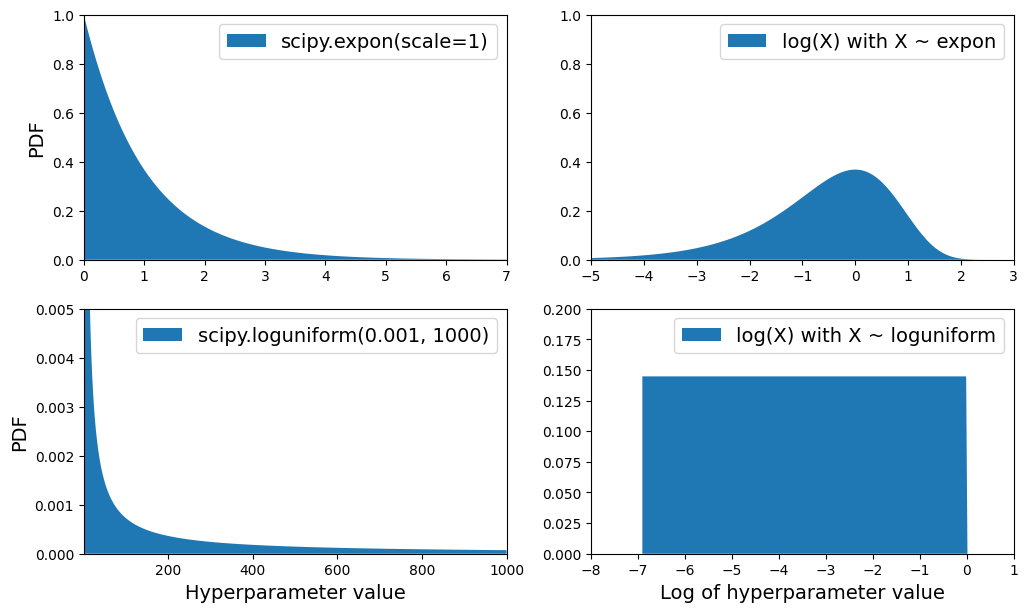

In [324]:
# código extra – mostra a diferença entre expon e loguniform

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib,
                 label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib,
                 label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib,
                 label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib,
                 label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

## Analisando os Melhores Modelos e Seus Erros

*Depois da busca, inspecionamos o melhor modelo para entender quais atributos foram mais importantes. Isso ajuda a validar se o modelo está aprendendo sinais plausíveis.*

In [325]:
final_model = rnd_search.best_estimator_  # inclui o pré-processamento
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.  ,
       0.01, 0.  , 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.03, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [326]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(np.float64(0.1898423270105783), 'log__median_income'),
 (np.float64(0.07709175866873944), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06455488601956336), 'bedrooms__ratio'),
 (np.float64(0.056936146643377976), 'rooms_per_house__ratio'),
 (np.float64(0.0490294770805355), 'people_per_house__ratio'),
 (np.float64(0.03807069074492323), 'geo__Similaridade com o cluster 3'),
 (np.float64(0.025643913400094476), 'geo__Similaridade com o cluster 22'),
 (np.float64(0.02179127543243723), 'geo__Similaridade com o cluster 17'),
 (np.float64(0.021575251507503695), 'geo__Similaridade com o cluster 6'),
 (np.float64(0.017868654556924362), 'geo__Similaridade com o cluster 2'),
 (np.float64(0.017431400050755975), 'geo__Similaridade com o cluster 32'),
 (np.float64(0.015981159400591683), 'geo__Similaridade com o cluster 18'),
 (np.float64(0.01488846425739688), 'geo__Similaridade com o cluster 40'),
 (np.float64(0.014488389218107143), 'geo__Similaridade com o cluster 43'),
 (np.float64(0.014252940099

## Avalie seu Sistema no Conjunto de Teste

*Somente agora usamos o conjunto de teste. Ele ficou separado durante todo o desenvolvimento para simular dados novos e fornecer uma estimativa final de desempenho.*

In [327]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

41549.20158097943


*Também podemos calcular um intervalo de confiança de 95% para o RMSE de teste. Isso dá uma noção da incerteza associada à métrica final.*

In [328]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval


In [329]:
rmse_lower, rmse_upper

(np.float64(39579.4379532319), np.float64(43805.02861542037))

## Persistência de Modelo usando joblib

*Depois de treinar e escolher o modelo final, salvamos o encadeamento completo. Isso inclui o pré-processamento e o regressor, permitindo reutilizar exatamente a mesma lógica em produção.*

*Salvando o modelo final:*

In [330]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

*Agora esse modelo pode ser implantado em produção. Por exemplo, o código abaixo poderia fazer parte de um script que carrega o modelo salvo e gera previsões para novos distritos.*

In [333]:
import joblib

# código extra – excluído por concisão
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # finja que estes são novos distritos
predictions = final_model_reloaded.predict(new_data)

In [332]:
predictions

array([439808.14, 455211.06, 109492.  ,  98208.  , 340021.04])

*Também seria possível usar `pickle`, mas `joblib` costuma ser mais eficiente para objetos grandes do ecossistema científico do Python.*